**Author**: Felipe Matheus  
**Start Date**: 06/05/2026  
**End Date**: 19/06/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [ ]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.modeling.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.Variables import Variables

%load_ext autoreload
%autoreload 2

In [66]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()


## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [ ]:
# ---- Experiment settings ----
TAG = "full-features_no-weight"
SCHEMA_DATE = "080626"

# ---- Paths ----
FILE_NAME = "dataset_annealing_iacs.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"

PROCESS = "annealing_iacs"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "iacs_final"
FEATURES = ["purity", "iacs", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = True           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.1 Schema data

In [6]:
# Schema dataset. Mark essay rows EXPLICITLY (used later for weight_col).
df_raw_schema = pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA))
df_schema = df_raw_schema[FEATURES + [TARGET]].dropna()
df_schema["is_essay"] = True
df_schema


,purity,iacs,temperature,time,iacs_final,is_essay
0,99.9,88.260,623.0,30.0,88.350000,True
1,99.9,88.260,623.0,60.0,88.655000,True
2,99.9,88.260,623.0,90.0,88.800000,True
3,99.9,99.825,573.0,30.0,102.340000,True
4,99.9,99.390,573.0,30.0,102.230000,True
5,99.9,99.390,588.0,30.0,101.346667,True
6,99.9,99.230,573.0,30.0,101.355000,True
7,99.9,98.720,573.0,30.0,101.480000,True
17,99.9,100.250,573.0,30.0,102.755000,True


## 2.2 Literature data

In [7]:
# Raw CSV.
df_raw = pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME))
df_raw

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,Cu,99.98,320,97,473,30,~500,100
1,Cu,99.98,320,97,523,600,~800,100
2,Cu,99.98,320,97,573,120,~900,103
3,Cu,99.98,320,96,473,30,~500,99
4,Cu,99.98,320,95,523,600,~800,98
...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,60,~2000,~67.4
127,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,120,~2500,~68.2
128,Al–Mn–Mg alloy,~99.5,250,~35,423,60,~400,~38
129,Al–Mn–Mg alloy,~99.5,250,~35,523,60,~800,~43


In [8]:
# Cast to float, label material elements, mark rows where ratios are valid.
df_float = proc.df_to_float(
    df_raw, drop_cols=["DOI"], ignore_columns=["material"]
)
df_labeled = feng.label_element(df_float).drop_duplicates()
df_with_masks = feng.add_ratio_mask_column(
    feng.add_ratio_mask_column(df_labeled, "grain_size"),
    "iacs",
)

# Keep only copper rows and the schema columns.
mask_cu = df_with_masks.has_Cu == True
df_lit = df_with_masks[mask_cu]
df_lit = df_lit[FEATURES + [TARGET]]
df_lit["is_essay"] = False

assert df_lit[FEATURES + [TARGET]].isna().sum().sum() == 0, "NaNs in inputs"
print(f"Dataset: {df_lit.shape}")
df_lit.head()


Dataset: (87, 6)


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(


,purity,iacs,temperature,time,iacs_final,is_essay
0,99.98,97.0,473.0,30.0,100.0,False
1,99.98,97.0,523.0,600.0,100.0,False
2,99.98,97.0,573.0,120.0,103.0,False
3,99.98,96.0,473.0,30.0,99.0,False
4,99.98,95.0,523.0,600.0,98.0,False


## 2.3 Concat dataset

In [9]:
df = pd.concat([df_schema, df_lit], ignore_index=True)

df["weight_col"] = np.where(df["is_essay"], WEIGHT_ON_ESSAY_ROWS, 1.0)

# Optional shared fold column: the SAME partition is passed to AutoGluon
# (groups=) and H2O (fold_column=) so OOF comparisons use identical folds.
if USE_SHARED_FOLDS:
    df = feng.add_stratified_fold_column(
        df, n_folds=NUM_BAG_FOLDS_A, seed=FOLD_SEED,
    )

df


,purity,iacs,temperature,time,iacs_final,is_essay,weight_col,fold_id
0,99.9,88.260,623.0,30.0,88.350,True,1.0,3
1,99.9,88.260,623.0,60.0,88.655,True,1.0,0
2,99.9,88.260,623.0,90.0,88.800,True,1.0,2
3,99.9,99.825,573.0,30.0,102.340,True,1.0,0
4,99.9,99.390,573.0,30.0,102.230,True,1.0,4
...,...,...,...,...,...,...,...,...
91,99.0,88.000,673.0,30.0,97.000,False,1.0,0
92,99.0,87.000,473.0,30.0,89.000,False,1.0,1
93,99.0,87.000,573.0,30.0,92.000,False,1.0,4
94,99.0,87.000,673.0,30.0,95.000,False,1.0,4


## 2.4 Validation data

In [49]:
# ---- Validation data ----
df_val = proc.load_validation_data_chimie_paris(
    path=os.path.join(varv.PATHS.data_processed, FILE_NAME_VALIDATION_DATA)
)


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [11]:
df.head(10)

,purity,iacs,temperature,time,iacs_final,is_essay,weight_col,fold_id
0,99.90,88.260,623.0,30.0,88.350000,True,1.0,3
1,99.90,88.260,623.0,60.0,88.655000,True,1.0,0
2,99.90,88.260,623.0,90.0,88.800000,True,1.0,2
3,99.90,99.825,573.0,30.0,102.340000,True,1.0,0
4,99.90,99.390,573.0,30.0,102.230000,True,1.0,4
5,99.90,99.390,588.0,30.0,101.346667,True,1.0,1
6,99.90,99.230,573.0,30.0,101.355000,True,1.0,2
7,99.90,98.720,573.0,30.0,101.480000,True,1.0,1
8,99.90,100.250,573.0,30.0,102.755000,True,1.0,3
9,99.98,97.000,473.0,30.0,100.000000,False,1.0,2


In [12]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    groups="fold_id" if USE_SHARED_FOLDS else None,
    sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       12.32 GB / 31.57 GB (39.0%)
Disk Space Avail:   754.77 GB / 932.08 GB (81.0%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Values in column 'weight_col' used as sample weights instead of predictive features. Evaluation metrics will ignore sample weights, specify weight_evaluation=True to instead report weighted metrics.
Values in column 'fold_id' used as split folds instead of being automatically set. Bagged models will have 5 splits.
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\full-features_no-we

In [13]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-3.611369,root_mean_squared_error,0.138063,70.552070,0.000000,0.015942,2,True,10
1,CatBoost_BAG_L1,-3.778108,root_mean_squared_error,0.017958,45.367826,0.017958,45.367826,1,True,4
2,LightGBMLarge_BAG_L1,-4.145759,root_mean_squared_error,0.017816,1.995367,0.017816,1.995367,1,True,9
3,NeuralNetTorch_BAG_L1,-4.174201,root_mean_squared_error,0.040418,13.346110,0.040418,13.346110,1,True,8
4,XGBoost_BAG_L1,-4.395605,root_mean_squared_error,0.018369,0.903445,0.018369,0.903445,1,True,7
5,ExtraTreesMSE_BAG_L1,-4.521245,root_mean_squared_error,0.302318,1.822138,0.302318,1.822138,1,True,5
6,RandomForestMSE_BAG_L1,-4.640209,root_mean_squared_error,0.272799,1.752688,0.272799,1.752688,1,True,3
7,NeuralNetFastAI_BAG_L1,-5.490744,root_mean_squared_error,0.061871,9.826825,0.061871,9.826825,1,True,6
8,LightGBM_BAG_L1,-6.406619,root_mean_squared_error,0.010128,1.854045,0.010128,1.854045,1,True,2
9,LightGBMXT_BAG_L1,-7.571952,root_mean_squared_error,0.007886,0.773357,0.007886,0.773357,1,True,1


In [14]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-3.611369,root_mean_squared_error,0.138063,70.552070,0.000000,0.015942,2,True,10
1,CatBoost_BAG_L1,-3.778108,root_mean_squared_error,0.017958,45.367826,0.017958,45.367826,1,True,4
2,LightGBMLarge_BAG_L1,-4.145759,root_mean_squared_error,0.017816,1.995367,0.017816,1.995367,1,True,9
3,NeuralNetTorch_BAG_L1,-4.174201,root_mean_squared_error,0.040418,13.346110,0.040418,13.346110,1,True,8
4,XGBoost_BAG_L1,-4.395605,root_mean_squared_error,0.018369,0.903445,0.018369,0.903445,1,True,7
5,ExtraTreesMSE_BAG_L1,-4.521245,root_mean_squared_error,0.302318,1.822138,0.302318,1.822138,1,True,5
6,RandomForestMSE_BAG_L1,-4.640209,root_mean_squared_error,0.272799,1.752688,0.272799,1.752688,1,True,3
7,NeuralNetFastAI_BAG_L1,-5.490744,root_mean_squared_error,0.061871,9.826825,0.061871,9.826825,1,True,6
8,LightGBM_BAG_L1,-6.406619,root_mean_squared_error,0.010128,1.854045,0.010128,1.854045,1,True,2
9,LightGBMXT_BAG_L1,-7.571952,root_mean_squared_error,0.007886,0.773357,0.007886,0.773357,1,True,1


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [ ]:
import h2o
from h2o.automl import H2OAutoML

h2o.init(nthreads=-1, max_mem_size="4G")

h2o_cols = FEATURES + [TARGET, "weight_col"]
if USE_SHARED_FOLDS:
    h2o_cols.append("fold_id")
train_h2o = h2o.H2OFrame(df[h2o_cols])
train_h2o[TARGET] = train_h2o[TARGET].asnumeric()
if USE_SHARED_FOLDS:
    # fold_column must be categorical on the H2O side.
    train_h2o["fold_id"] = train_h2o["fold_id"].asfactor()

aml_kwargs = dict(
    max_runtime_secs=TIME_LIMIT_A,
    keep_cross_validation_predictions=True,
    exclude_algos=["DeepLearning"],
    sort_metric="RMSE",
    seed=42,
)
if not USE_SHARED_FOLDS:
    aml_kwargs["nfolds"] = NUM_BAG_FOLDS_A  # nfolds is ignored/conflicting with fold_column

aml_h2o = H2OAutoML(**aml_kwargs)

train_kwargs = dict(x=FEATURES, y=TARGET, training_frame=train_h2o,
                    weights_column="weight_col")
if USE_SHARED_FOLDS:
    train_kwargs["fold_column"] = "fold_id"

aml_h2o.train(**train_kwargs)

aml_h2o.leaderboard.head(10)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 24.0.2+12-54, mixed mode, sharing)
  Starting server from C:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\fmfoa\AppData\Local\Temp\tmp4ld6bkyy
  JVM stdout: C:\Users\fmfoa\AppData\Local\Temp\tmp4ld6bkyy\h2o_fmfoa_started_from_python.out
  JVM stderr: C:\Users\fmfoa\AppData\Local\Temp\tmp4ld6bkyy\h2o_fmfoa_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,3 months and 6 days
H2O_cluster_name:,H2O_from_python_fmfoa_0mp6sl
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.983 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
11:29:52.23: Fold column fold_id will be used for cross-validation. nfolds parameter will be ignored.
11:29:52.33: AutoML: XGBoost is not available; skipping it.


11:29:52.564: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 96.0.

███
11:29:54.170: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.
11:29:54.317: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.

██████████
11:29:57.54: _weights_column param, All base models use wei

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_1_20260618_112952_model_290,3.89789,15.1936,2.36255,0.0497518,15.1936
GBM_grid_1_AutoML_1_20260618_112952_model_51,3.9306,15.4496,2.63237,0.0495979,15.4496
StackedEnsemble_BestOfFamily_3_AutoML_1_20260618_112952,3.94522,15.5648,2.37983,0.0495983,15.5648
GBM_grid_1_AutoML_1_20260618_112952_model_191,3.97984,15.8391,2.07846,0.0508507,15.8391
GBM_grid_1_AutoML_1_20260618_112952_model_64,4.00991,16.0794,2.31805,0.0515641,16.0794
StackedEnsemble_AllModels_4_AutoML_1_20260618_112952,4.05518,16.4445,2.62882,0.0535065,16.4445
StackedEnsemble_AllModels_3_AutoML_1_20260618_112952,4.07871,16.6359,2.69948,0.0535324,16.6359
GBM_grid_1_AutoML_1_20260618_112952_model_272,4.09241,16.7478,2.62005,0.0522174,16.7478
GBM_grid_1_AutoML_1_20260618_112952_model_55,4.14097,17.1476,2.49646,0.0526207,17.1476
GBM_grid_1_AutoML_1_20260618_112952_model_206,4.14319,17.166,2.30242,0.0534692,17.166


In [16]:
# NOTE: the previous cell here compared AutoGluon's `score_val` against
# H2O's xval RMSE. That comparison is incoherent when sample weights are
# active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
# score_val is UNWEIGHTED unless weight_evaluation=True. The fair,
# like-for-like comparison (unweighted metrics on OOF predictions of both
# engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
# Section 10 ("OOF metrics: AutoGluon vs H2O").
print("See Section 10 for the coherent OOF-vs-OOF comparison.")


See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [17]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(96,)  any NaN? False


## 4.1 fast check on big residuals

In [18]:
residuals_oof.head(10)

0   -3.715590
1   -3.314009
2   -4.298534
3    0.093975
4    0.648167
5   -0.518232
6   -0.275028
7    0.126469
8    0.657565
9    0.536125
Name: iacs_final, dtype: float64

In [19]:
df[residuals_oof.abs() > 2]

,purity,iacs,temperature,time,iacs_final,is_essay,weight_col,fold_id
0,99.90,88.26,623.0,30.0,88.350,True,1.0,3
1,99.90,88.26,623.0,60.0,88.655,True,1.0,0
2,99.90,88.26,623.0,90.0,88.800,True,1.0,2
11,99.98,97.00,573.0,120.0,103.000,False,1.0,3
16,99.50,57.00,400.0,90.0,89.000,False,1.0,3
17,99.50,57.00,673.0,90.0,92.000,False,1.0,0
18,99.80,55.00,373.0,30.0,60.000,False,1.0,2
19,99.80,55.00,473.0,30.0,80.000,False,1.0,4
20,99.80,55.00,573.0,30.0,85.000,False,1.0,2
21,99.80,81.00,373.0,30.0,82.000,False,1.0,4


## 4.2 Recovering weights 

In [20]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (9, 96)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1']


In [21]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000004  (OK)

Non-zero weights:
  CatBoost_BAG_L1                 0.4667
  NeuralNetFastAI_BAG_L1          0.1333
  NeuralNetTorch_BAG_L1           0.2000
  LightGBMLarge_BAG_L1            0.2000


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [22]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    9.600000e+01
mean     1.636476e-06
std      1.125734e-06
min      9.616201e-09
25%      5.829641e-07
50%      1.550376e-06
75%      2.531828e-06
max      4.483181e-06
Name: iacs_final, dtype: float64

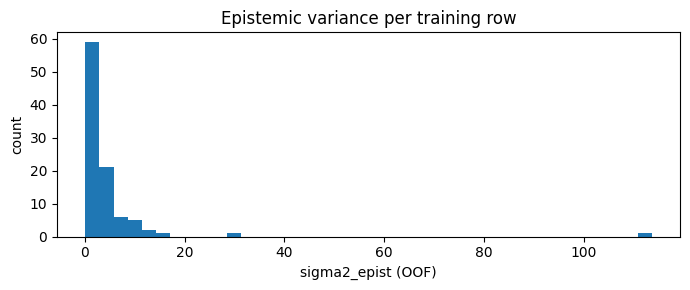

In [23]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [24]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    96.000000
mean      0.882680
std       0.999265
min       0.020386
25%       0.231180
50%       0.583809
75%       1.097168
max       5.095158
Name: iacs_final, dtype: float64

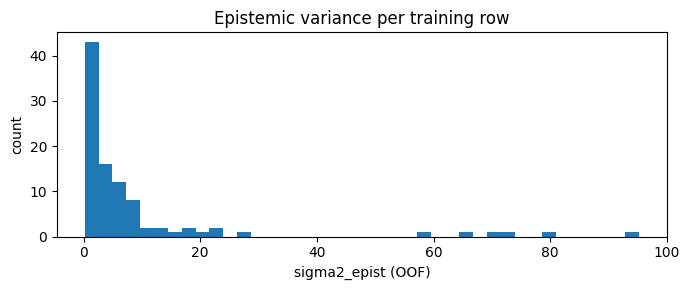

In [25]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [26]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 96
  n_truncated          = 50
  pct_truncated        = 52.083333333333336
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 239.05642502037304
  r_tilde_sq_mean      = 9.390930866904473
  r_tilde_sq_median    = 0.0


In [27]:
r_tilde_sq

array([6.74836331e+00, 4.05320569e+00, 1.37598856e+01, 0.00000000e+00,
       1.77394900e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.24811072e+01,
       0.00000000e+00, 0.00000000e+00, 1.13740745e+00, 0.00000000e+00,
       2.23314053e+02, 6.74033175e+01, 2.39056425e+02, 0.00000000e+00,
       3.69422337e+01, 0.00000000e+00, 0.00000000e+00, 5.02204125e+00,
       1.99091467e+01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.35194324e+01, 3.79571389e+00, 7.13829488e+00, 3.53515042e+00,
       0.00000000e+00, 0.00000000e+00, 3.86958511e+00, 3.59013201e+01,
       0.00000000e+00, 0.00000000e+00, 4.18763099e+01, 2.11966640e+01,
       0.00000000e+00, 4.68569733e+00, 0.00000000e+00, 0.00000000e+00,
       6.95485184e-01, 0.00000000e+00, 1.13722788e+00, 0.00000000e+00,
       0.00000000e+00, 8.48246329e+00, 1.11974343e+01, 6.17252526e-01,
       0.00000000e+00, 0.00000000e+00, 3.17460409e+00, 0.00000000e+00,
      

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [28]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       9.25 GB / 31.57 GB (29.3%)
Disk Space Avail:   754.68 GB / 932.08 GB (81.0%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\full-features_no-weight\model_b"
Train Data Rows:    96
Train Data Columns: 4
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (5.4766996162016, -13.815510557964274, -6.4377, 

In [29]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-6.881349,root_mean_squared_error,0.142779,11.828156,0.000000,0.009520,2,True,10
1,NeuralNetFastAI_BAG_L1,-7.016002,root_mean_squared_error,0.053523,9.299257,0.053523,9.299257,1,True,6
2,LightGBM_BAG_L1,-7.182242,root_mean_squared_error,0.005008,1.953817,0.005008,1.953817,1,True,2
3,CatBoost_BAG_L1,-7.217302,root_mean_squared_error,0.008002,2.645047,0.008002,2.645047,1,True,4
4,LightGBMXT_BAG_L1,-7.329643,root_mean_squared_error,0.018560,1.615850,0.018560,1.615850,1,True,1
5,ExtraTreesMSE_BAG_L1,-7.487971,root_mean_squared_error,0.084249,0.565562,0.084249,0.565562,1,True,5
6,LightGBMLarge_BAG_L1,-7.499278,root_mean_squared_error,0.005530,1.343318,0.005530,1.343318,1,True,9
7,XGBoost_BAG_L1,-7.584409,root_mean_squared_error,0.019109,0.816387,0.019109,0.816387,1,True,7
8,NeuralNetTorch_BAG_L1,-7.658449,root_mean_squared_error,0.037095,8.985284,0.037095,8.985284,1,True,8
9,RandomForestMSE_BAG_L1,-7.687716,root_mean_squared_error,0.060157,0.690883,0.060157,0.690883,1,True,3


In [30]:
predictor_b.predict_oof()  

0     -4.608511
1     -3.688074
2     -4.555847
3    -10.022374
4    -10.488422
        ...    
91    -6.336700
92   -11.755157
93    -8.948949
94    -2.097506
95    -4.494000
Name: log_r_tilde_sq, Length: 96, dtype: float32

In [31]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof()  , 
    "epistemic_error": sigma2_epist_oof,
    "iacs": df["iacs"],
    "iacs_final": df[TARGET]
}) 
df_lado_a_lado

,residual_oof,predict_random_error,epistemic_error,iacs,iacs_final
0,-3.715590,-4.608511,7.057245,88.260,88.350
1,-3.314009,-3.688074,6.929453,88.260,88.655
2,-4.298534,-4.555847,4.717506,88.260,88.800
3,0.093975,-10.022374,0.718793,99.825,102.340
4,0.648167,-10.488422,0.242726,99.390,102.230
...,...,...,...,...,...
91,1.451180,-6.336700,0.133374,88.000,97.000
92,-0.849274,-11.755157,1.030290,87.000,89.000
93,0.250648,-8.948949,0.942312,87.000,92.000
94,-0.779236,-2.097506,1.033500,87.000,95.000


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [46]:
df[TARGET].var()

np.float64(141.17059220871857)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [47]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.489583,-0.010417
1,0.80,0.739583,-0.060417
2,0.90,0.822917,-0.077083
3,0.95,0.885417,-0.064583


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [48]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 1.2471

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.541667,0.041667
1,0.80,0.822917,0.022917
2,0.90,0.895833,-0.004167
3,0.95,0.947917,-0.002083


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [54]:
c_opt
weights

array([0.00000000e+00, 5.31610624e-08, 9.69689902e-08, 4.66666659e-01,
       2.37450643e-08, 1.33333296e-01, 0.00000000e+00, 1.99999864e-01,
       2.00000008e-01])

In [57]:
len(base_model_names)
len(weights)

9

In [59]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df_val, # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df_val, #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 0.6635, 'mae': 0.5639, 'mape': 0.559, 'r2': -0.9904}
coverage: {0.5: 1.0, 0.8: 1.0, 0.9: 1.0, 0.95: 1.0}


In [60]:
val_metrics

{'rmse': 0.6634712232411377,
 'mae': 0.5638755623005847,
 'mape': 0.5589753556071076,
 'r2': -0.9904273395407273,
 'coverage': {0.5: 1.0, 0.8: 1.0, 0.9: 1.0, 0.95: 1.0}}

In [52]:
df_val

,id,purity,initial_diameter,iacs,temperature,time,iacs_final
0,C1_250_30m_T1,99.95,1.2,98.47,523,30,101.08
1,C1_250_30m_T3,99.95,1.2,98.47,523,30,101.08
2,C1_250_60m_T1,99.95,1.2,98.47,523,60,100.82
3,C1_250_60m_T2,99.95,1.2,98.47,523,60,100.82
4,C1_250_90m_T1,99.95,1.2,98.47,523,90,101.22
5,C1_250_90m_T2,99.95,1.2,98.47,523,90,101.22
6,C1_250_30m_AQ_T1,99.95,1.2,98.47,523,30,100.95
7,C1_250_30m_AQ_T2,99.95,1.2,98.47,523,30,100.95
8,C1_300_30m_T1,99.95,1.2,98.47,573,30,102.03
9,C1_300_30m_T2,99.95,1.2,98.47,573,30,102.03


In [51]:
preds_val

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
1,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
2,100.614161,0.304952,1.411706,2.669927,1.633991,100.614159,1.0,100.596325,1.609777,0.003636
3,100.614161,0.304952,1.411706,2.669927,1.633991,100.614159,1.0,100.596325,1.609777,0.003636
4,99.853588,1.404557,1.411706,4.380150,2.092881,99.853584,1.0,99.812694,2.041573,0.006966
5,99.853588,1.404557,1.411706,4.380150,2.092881,99.853584,1.0,99.812694,2.041573,0.006966
6,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
7,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
8,101.368072,0.232564,1.411706,2.557342,1.599169,101.368073,1.0,101.319116,1.541799,0.011569
9,101.368072,0.232564,1.411706,2.557342,1.599169,101.368073,1.0,101.319116,1.541799,0.011569


In [35]:
# ---- Target-agnostic point prediction from a plain dict ----
single = modl.predict_target(
    predictor_a,
    {"purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
)
print(f"Predicted {TARGET}: {single[0]:.3f}")

Predicted iacs_final: 91.369


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [36]:
df.head(5)

,purity,iacs,temperature,time,iacs_final,is_essay,weight_col,fold_id
0,99.9,88.260,623.0,30.0,88.350,True,1.0,3
1,99.9,88.260,623.0,60.0,88.655,True,1.0,0
2,99.9,88.260,623.0,90.0,88.800,True,1.0,2
3,99.9,99.825,573.0,30.0,102.340,True,1.0,0
4,99.9,99.390,573.0,30.0,102.230,True,1.0,4


In [61]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df_val.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
1,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
2,100.614161,0.304952,1.411706,2.669927,1.633991,100.614159,1.0,100.596325,1.609777,0.003636
3,100.614161,0.304952,1.411706,2.669927,1.633991,100.614159,1.0,100.596325,1.609777,0.003636
4,99.853588,1.404557,1.411706,4.380150,2.092881,99.853584,1.0,99.812694,2.041573,0.006966


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [38]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_iacs\full-features_no-weight\artifacts.pkl


In [39]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_iacs\full-features_no-weight\global_config.txt


In [40]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


                         model      rmse       mae      mape        r2
0  AutoGluon (Model A, leader)  3.611369  2.271929  2.826756  0.906643
1          H2O AutoML (leader)  3.897893  2.362550  2.973904  0.891242
Saved to: ../../models/annealing_iacs\full-features_no-weight


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [ ]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: iacs_final
Features: ['purity', 'iacs', 'temperature', 'time']


In [67]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df_val.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
1,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
2,100.614161,0.304952,1.411706,2.669927,1.633991,100.614159,1.0,100.596325,1.609777,0.003636
3,100.614161,0.304952,1.411706,2.669927,1.633991,100.614159,1.0,100.596325,1.609777,0.003636
4,99.853588,1.404557,1.411706,4.380150,2.092881,99.853584,1.0,99.812694,2.041573,0.006966


In [68]:
# ---- 4) Target-agnostic quick prediction from a plain dict ----
# Works for any predictor/target via modl.predict_target (features inferred
# from the predictor when not passed explicitly).
single_loaded = modl.predict_target(
    predictor_a_loaded,
    {"purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
    features=loaded_artifacts["features"],
)
print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

Predicted iacs_final: 91.369


In [69]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
